In [ ]:
#Name: Aashish Singh , Section: Q , Roll No.: 20

In [ ]:
"""
Problem Statement: 3
"""

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import re 

In [67]:
# Load datasets
df1 = pd.read_csv("medical_records.csv")
df2 = pd.read_csv("patient_details.csv") 

In [68]:
#i.) Merge both the datasets on patient_id column and using inner join.
df = pd.merge(df1, df2, on="patient_id", how="inner")
print("\nMerged Data:\n", df) 


Merged Data:
    patient_id     diagnosis admission_date height_cm      bp  sugar_level  \
0         101      Diabetes     12-01-2024     170cm    high        180.0   
1         102  Hypertension     2024/02/15     165cm  130/85          NaN   
2         103           Flu    15 Mar 2024     5.6ft  120/80        110.0   
3         104      Diabetes     01-04-2024     160cm    high        200.0   
4         105        Asthma     2024-05-20    172 cm  125/85        140.0   
5         106       Allergy     18-06-2024     168cm    high        130.0   
6         107      Covid-19     2024/07/10     5.8ft  140/90          NaN   
7         108           Flu    25 Aug 2024     155cm  120/80        100.0   
8         109  Hypertension     2024-09-05    180 cm    high        160.0   
9         110      Diabetes     10-10-2024     5.5ft  135/88          NaN   

   visit_cost    name  age gender       city  
0        2000   Rahul  -25      M      delhi  
1        1500     NaN   30      F     Mumba

In [56]:
#ii.) Impute null values in name column with value “unknown”. 
df["name"] = df["name"].fillna("unknown") 
df

,patient_id,diagnosis,admission_date,height_cm,bp,sugar_level,visit_cost,name,age,gender,city
0,101,Diabetes,12-01-2024,170cm,high,180.0,2000,Rahul,-25,M,delhi
1,102,Hypertension,2024/02/15,165cm,130/85,NaN,1500,unknown,30,F,Mumbai
2,103,Flu,15 Mar 2024,5.6ft,120/80,110.0,800,Amit,28,m,DELHI
3,104,Diabetes,01-04-2024,160cm,high,200.0,2200,Sneha,-40,F,chennai
4,105,Asthma,2024-05-20,172 cm,125/85,140.0,1800,Arjun,35,M,bangalore
5,106,Allergy,18-06-2024,168cm,high,130.0,900,Pooja,22,f,KOLKATA
6,107,Covid-19,2024/07/10,5.8ft,140/90,NaN,2500,Karan,-31,M,delhi
7,108,Flu,25 Aug 2024,155cm,120/80,100.0,700,Neha,27,F,Mumbai
8,109,Hypertension,2024-09-05,180 cm,high,160.0,2100,unknown,45,m,CHENNAI
9,110,Diabetes,10-10-2024,5.5ft,135/88,NaN,1900,Vikram,-50,M,bangalore


In [57]:
#iii.) Rectify the negative values present in age column.
df["age"] = df["age"].apply(lambda x: abs(x)) 
df["age"]

0    25
1    30
2    28
3    40
4    35
5    22
6    31
7    27
8    45
9    50
Name: age, dtype: int64

In [69]:
#iv. Make the values in gender column consistent by converting values M to Male and F to Female or vice-versa. 
df['gender'] = df['gender'].astype(str).str.strip().str.upper()

df['gender'] = df['gender'].replace({
    'M': 'Male',
    'F': 'Female'
})

df

,patient_id,diagnosis,admission_date,height_cm,bp,sugar_level,visit_cost,name,age,gender,city
0,101,Diabetes,12-01-2024,170cm,high,180.0,2000,Rahul,-25,Male,delhi
1,102,Hypertension,2024/02/15,165cm,130/85,NaN,1500,NaN,30,Female,Mumbai
2,103,Flu,15 Mar 2024,5.6ft,120/80,110.0,800,Amit,28,Male,DELHI
3,104,Diabetes,01-04-2024,160cm,high,200.0,2200,Sneha,-40,Female,chennai
4,105,Asthma,2024-05-20,172 cm,125/85,140.0,1800,Arjun,35,Male,bangalore
5,106,Allergy,18-06-2024,168cm,high,130.0,900,Pooja,22,Female,KOLKATA
6,107,Covid-19,2024/07/10,5.8ft,140/90,NaN,2500,Karan,-31,Male,delhi
7,108,Flu,25 Aug 2024,155cm,120/80,100.0,700,Neha,27,Female,Mumbai
8,109,Hypertension,2024-09-05,180 cm,high,160.0,2100,NaN,45,Male,CHENNAI
9,110,Diabetes,10-10-2024,5.5ft,135/88,NaN,1900,Vikram,-50,Male,bangalore


In [70]:
#v.) Make the case of values in city column consistent. 
df["city"] = df["city"].str.title() 
df["city"]

0        Delhi
1       Mumbai
2        Delhi
3      Chennai
4    Bangalore
5      Kolkata
6        Delhi
7       Mumbai
8      Chennai
9    Bangalore
Name: city, dtype: str

In [71]:
#vi.) Make the date format of admission_date consistent using regular expression. 
def fix_date(date):
    try:
        return pd.to_datetime(date, dayfirst=True).strftime("%Y-%m-%d")
    except:
        return np.nan
df 

,patient_id,diagnosis,admission_date,height_cm,bp,sugar_level,visit_cost,name,age,gender,city
0,101,Diabetes,12-01-2024,170cm,high,180.0,2000,Rahul,-25,Male,Delhi
1,102,Hypertension,2024/02/15,165cm,130/85,NaN,1500,NaN,30,Female,Mumbai
2,103,Flu,15 Mar 2024,5.6ft,120/80,110.0,800,Amit,28,Male,Delhi
3,104,Diabetes,01-04-2024,160cm,high,200.0,2200,Sneha,-40,Female,Chennai
4,105,Asthma,2024-05-20,172 cm,125/85,140.0,1800,Arjun,35,Male,Bangalore
5,106,Allergy,18-06-2024,168cm,high,130.0,900,Pooja,22,Female,Kolkata
6,107,Covid-19,2024/07/10,5.8ft,140/90,NaN,2500,Karan,-31,Male,Delhi
7,108,Flu,25 Aug 2024,155cm,120/80,100.0,700,Neha,27,Female,Mumbai
8,109,Hypertension,2024-09-05,180 cm,high,160.0,2100,NaN,45,Male,Chennai
9,110,Diabetes,10-10-2024,5.5ft,135/88,NaN,1900,Vikram,-50,Male,Bangalore


In [74]:
#vii.) Remove string value from height_cm column and impute the values. 
# Extract numbers from height
df["height_cm"] = df["height_cm"].astype(str).str.extract(r'(\d+)')

# Convert to numeric
df["height_cm"] = pd.to_numeric(df["height_cm"], errors='coerce')

# Fill missing values with mean
df["height_cm"] = df["height_cm"].fillna(df["height_cm"].mean()) 
df

,patient_id,diagnosis,admission_date,height_cm,bp,sugar_level,visit_cost,name,age,gender,city
0,101,Diabetes,12-01-2024,170,high,180.0,2000,Rahul,-25,Male,Delhi
1,102,Hypertension,2024/02/15,165,130/85,NaN,1500,NaN,30,Female,Mumbai
2,103,Flu,15 Mar 2024,5,120/80,110.0,800,Amit,28,Male,Delhi
3,104,Diabetes,01-04-2024,160,high,200.0,2200,Sneha,-40,Female,Chennai
4,105,Asthma,2024-05-20,172,125/85,140.0,1800,Arjun,35,Male,Bangalore
5,106,Allergy,18-06-2024,168,high,130.0,900,Pooja,22,Female,Kolkata
6,107,Covid-19,2024/07/10,5,140/90,NaN,2500,Karan,-31,Male,Delhi
7,108,Flu,25 Aug 2024,155,120/80,100.0,700,Neha,27,Female,Mumbai
8,109,Hypertension,2024-09-05,180,high,160.0,2100,NaN,45,Male,Chennai
9,110,Diabetes,10-10-2024,5,135/88,NaN,1900,Vikram,-50,Male,Bangalore


In [75]:
#viii.) Replace “high” from bp column with 140/90.
df["bp"] = df["bp"].replace("high", "140/90")
df 

,patient_id,diagnosis,admission_date,height_cm,bp,sugar_level,visit_cost,name,age,gender,city
0,101,Diabetes,12-01-2024,170,140/90,180.0,2000,Rahul,-25,Male,Delhi
1,102,Hypertension,2024/02/15,165,130/85,NaN,1500,NaN,30,Female,Mumbai
2,103,Flu,15 Mar 2024,5,120/80,110.0,800,Amit,28,Male,Delhi
3,104,Diabetes,01-04-2024,160,140/90,200.0,2200,Sneha,-40,Female,Chennai
4,105,Asthma,2024-05-20,172,125/85,140.0,1800,Arjun,35,Male,Bangalore
5,106,Allergy,18-06-2024,168,140/90,130.0,900,Pooja,22,Female,Kolkata
6,107,Covid-19,2024/07/10,5,140/90,NaN,2500,Karan,-31,Male,Delhi
7,108,Flu,25 Aug 2024,155,120/80,100.0,700,Neha,27,Female,Mumbai
8,109,Hypertension,2024-09-05,180,140/90,160.0,2100,NaN,45,Male,Chennai
9,110,Diabetes,10-10-2024,5,135/88,NaN,1900,Vikram,-50,Male,Bangalore


In [76]:
#ix.) Impute sugar_level with mean value. 
df["sugar_level"] = df["sugar_level"].fillna(df["sugar_level"].mean()) 
df 

,patient_id,diagnosis,admission_date,height_cm,bp,sugar_level,visit_cost,name,age,gender,city
0,101,Diabetes,12-01-2024,170,140/90,180.000000,2000,Rahul,-25,Male,Delhi
1,102,Hypertension,2024/02/15,165,130/85,145.714286,1500,NaN,30,Female,Mumbai
2,103,Flu,15 Mar 2024,5,120/80,110.000000,800,Amit,28,Male,Delhi
3,104,Diabetes,01-04-2024,160,140/90,200.000000,2200,Sneha,-40,Female,Chennai
4,105,Asthma,2024-05-20,172,125/85,140.000000,1800,Arjun,35,Male,Bangalore
5,106,Allergy,18-06-2024,168,140/90,130.000000,900,Pooja,22,Female,Kolkata
6,107,Covid-19,2024/07/10,5,140/90,145.714286,2500,Karan,-31,Male,Delhi
7,108,Flu,25 Aug 2024,155,120/80,100.000000,700,Neha,27,Female,Mumbai
8,109,Hypertension,2024-09-05,180,140/90,160.000000,2100,NaN,45,Male,Chennai
9,110,Diabetes,10-10-2024,5,135/88,145.714286,1900,Vikram,-50,Male,Bangalore


In [77]:
#x.) Perform group by operation on gender column and compute mean, min and max of visit_cost for each gender.
grouped = df.groupby('gender')['visit_cost'].agg(['mean', 'min', 'max'])
print(grouped)

          mean  min   max
gender                   
Female  1325.0  700  2200
Male    1850.0  800  2500


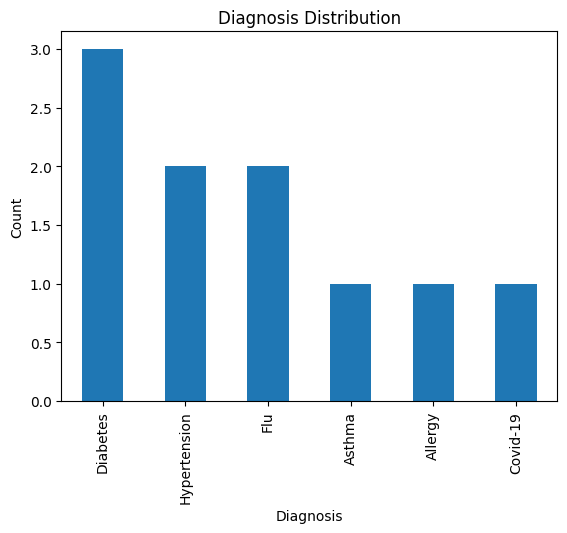

In [78]:
#xi.) Plot a histogram on diagnosis column. 
plt.figure()
df['diagnosis'].value_counts().plot(kind='bar')
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Diagnosis Distribution")
plt.show()

In [79]:
# Final dataset
print(df)

   patient_id     diagnosis admission_date  height_cm      bp  sugar_level  \
0         101      Diabetes     12-01-2024        170  140/90   180.000000   
1         102  Hypertension     2024/02/15        165  130/85   145.714286   
2         103           Flu    15 Mar 2024          5  120/80   110.000000   
3         104      Diabetes     01-04-2024        160  140/90   200.000000   
4         105        Asthma     2024-05-20        172  125/85   140.000000   
5         106       Allergy     18-06-2024        168  140/90   130.000000   
6         107      Covid-19     2024/07/10          5  140/90   145.714286   
7         108           Flu    25 Aug 2024        155  120/80   100.000000   
8         109  Hypertension     2024-09-05        180  140/90   160.000000   
9         110      Diabetes     10-10-2024          5  135/88   145.714286   

   visit_cost    name  age  gender       city  
0        2000   Rahul  -25    Male      Delhi  
1        1500     NaN   30  Female     Mumbai